In [1]:
import pandas as pd
log_path = r'prueba2.csv'
df_log = pd.read_csv(log_path, dtype=str)
df_log

,time,ts,utm_x,utm_y,z,utm_zone_n,utm_zone_l,heading,inx_x,inx_y,inx_z,inx_yaw,raw
0,1784672294328,CA9B640000000000,C7D0AA01,0781A033,662D0000,12000000,4C000000,6E730000,BD000000,00000000,FEFFFFFF,EFFFFFFF,CA9B640000000000C7D0AA010781A033662D0000120000...
1,1784672294328,2F9C640000000000,06D1AA01,0781A033,662D0000,12000000,4C000000,6E730000,FC000000,00000000,FDFFFFFF,EFFFFFFF,2F9C64000000000006D1AA010781A033662D0000120000...
2,1784672294328,929C640000000000,45D1AA01,0781A033,662D0000,12000000,4C000000,6E730000,3B010000,00000000,FCFFFFFF,EFFFFFFF,929C64000000000045D1AA010781A033662D0000120000...
3,1784672294328,F69C640000000000,84D1AA01,0781A033,662D0000,12000000,4C000000,6E730000,7A010000,00000000,FBFFFFFF,EFFFFFFF,F69C64000000000084D1AA010781A033662D0000120000...
4,1784672294328,5A9D640000000000,BFD1AA01,0781A033,662D0000,12000000,4C000000,6E730000,B5010000,00000000,FAFFFFFF,EFFFFFFF,5A9D640000000000BFD1AA010781A033662D0000120000...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1621,1784672458328,401D670000000000,84A3A901,A767A033,662D0000,12000000,4C000000,FD530000,E0090100,57990000,97FCFFFF,7EE0FFFF,401D67000000000084A3A901A767A033662D0000120000...
1622,1784672458328,A41D670000000000,5EA3A901,7467A033,662D0000,12000000,4C000000,FD530000,EC090100,95990000,97FCFFFF,7EE0FFFF,A41D6700000000005EA3A9017467A033662D0000120000...
1623,1784672458328,081E670000000000,39A3A901,4167A033,662D0000,12000000,4C000000,FD530000,F8090100,D3990000,97FCFFFF,7EE0FFFF,081E67000000000039A3A9014167A033662D0000120000...
1624,1784672458328,6C1E670000000000,16A3A901,1267A033,662D0000,12000000,4C000000,FD530000,030A0100,0C9A0000,97FCFFFF,7EE0FFFF,6C1E67000000000016A3A9011267A033662D0000120000...


In [2]:
# Columnas hexadecimales little-endian (excluimos 'time' que ya es decimal, y 'raw' que es la concatenación)
hex_cols = [c for c in df_log.columns if c not in ("time", "raw")]

def hex_to_int(x):
    return int.from_bytes(bytes.fromhex(x), byteorder="little", signed=True)

for column in hex_cols:
    df_log[column] = df_log[column].apply(hex_to_int)

# 'time' es epoch en ms (entero decimal), lo convertimos aparte
df_log["time"] = df_log["time"].astype("int64")

df_log

,time,ts,utm_x,utm_y,z,utm_zone_n,utm_zone_l,heading,inx_x,inx_y,inx_z,inx_yaw,raw
0,1784672294328,6593482,27971783,866156807,11622,18,76,29550,189,0,-2,-17,CA9B640000000000C7D0AA010781A033662D0000120000...
1,1784672294328,6593583,27971846,866156807,11622,18,76,29550,252,0,-3,-17,2F9C64000000000006D1AA010781A033662D0000120000...
2,1784672294328,6593682,27971909,866156807,11622,18,76,29550,315,0,-4,-17,929C64000000000045D1AA010781A033662D0000120000...
3,1784672294328,6593782,27971972,866156807,11622,18,76,29550,378,0,-5,-17,F69C64000000000084D1AA010781A033662D0000120000...
4,1784672294328,6593882,27972031,866156807,11622,18,76,29550,437,0,-6,-17,5A9D640000000000BFD1AA010781A033662D0000120000...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1621,1784672458328,6757696,27894660,866150311,11622,18,76,21501,68064,39255,-873,-8066,401D67000000000084A3A901A767A033662D0000120000...
1622,1784672458328,6757796,27894622,866150260,11622,18,76,21501,68076,39317,-873,-8066,A41D6700000000005EA3A9017467A033662D0000120000...
1623,1784672458328,6757896,27894585,866150209,11622,18,76,21501,68088,39379,-873,-8066,081E67000000000039A3A9014167A033662D0000120000...
1624,1784672458328,6757996,27894550,866150162,11622,18,76,21501,68099,39436,-873,-8066,6C1E67000000000016A3A9011267A033662D0000120000...


In [3]:
# Escalado a unidades reales (confirmado contra ControlBox_prueba1.db y por consistencia interna)
# Todos los enteros vienen en centesimas (valor x100): posicion/altura en cm, angulos en centesimas de grado.
#   z=11622 -> 116.22 (IBeacon.altitude), heading=29549 -> 295.49 (HeadingBeacon=295.5)
#   inx_x=99985 -> 999.85 m ~= distancia UTM recorrida (~993 m)
#   inx_yaw=-136 -> -1.36 deg ~= variacion de heading (-1.23 deg)

df_log["utm_x"]   = df_log["utm_x"] / 100.0        # m (UTM Este)
df_log["utm_y"]   = df_log["utm_y"] / 100.0        # m (UTM Norte)
df_log["z"]       = df_log["z"] / 100.0            # m (altura)
df_log["heading"] = df_log["heading"] / 100.0      # grados

df_log["utm_zone_l"] = df_log["utm_zone_l"].apply(chr)   # 76 -> 'L'
# utm_zone_n queda como entero (18)

# Offsets INS relativos a la baliza (mismo factor: centesimas)
df_log["inx_x"]   = df_log["inx_x"] / 100.0        # m
df_log["inx_y"]   = df_log["inx_y"] / 100.0        # m
df_log["inx_z"]   = df_log["inx_z"] / 100.0        # m
df_log["inx_yaw"] = df_log["inx_yaw"] / 100.0      # grados

# time a datetime (epoch ms)
df_log["time"] = pd.to_datetime(df_log["time"], unit="ms")

df_log

,time,ts,utm_x,utm_y,z,utm_zone_n,utm_zone_l,heading,inx_x,inx_y,inx_z,inx_yaw,raw
0,2026-07-21 22:18:14.328,6593482,279717.83,8661568.07,116.22,18,L,295.50,1.89,0.00,-0.02,-0.17,CA9B640000000000C7D0AA010781A033662D0000120000...
1,2026-07-21 22:18:14.328,6593583,279718.46,8661568.07,116.22,18,L,295.50,2.52,0.00,-0.03,-0.17,2F9C64000000000006D1AA010781A033662D0000120000...
2,2026-07-21 22:18:14.328,6593682,279719.09,8661568.07,116.22,18,L,295.50,3.15,0.00,-0.04,-0.17,929C64000000000045D1AA010781A033662D0000120000...
3,2026-07-21 22:18:14.328,6593782,279719.72,8661568.07,116.22,18,L,295.50,3.78,0.00,-0.05,-0.17,F69C64000000000084D1AA010781A033662D0000120000...
4,2026-07-21 22:18:14.328,6593882,279720.31,8661568.07,116.22,18,L,295.50,4.37,0.00,-0.06,-0.17,5A9D640000000000BFD1AA010781A033662D0000120000...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1621,2026-07-21 22:20:58.328,6757696,278946.60,8661503.11,116.22,18,L,215.01,680.64,392.55,-8.73,-80.66,401D67000000000084A3A901A767A033662D0000120000...
1622,2026-07-21 22:20:58.328,6757796,278946.22,8661502.60,116.22,18,L,215.01,680.76,393.17,-8.73,-80.66,A41D6700000000005EA3A9017467A033662D0000120000...
1623,2026-07-21 22:20:58.328,6757896,278945.85,8661502.09,116.22,18,L,215.01,680.88,393.79,-8.73,-80.66,081E67000000000039A3A9014167A033662D0000120000...
1624,2026-07-21 22:20:58.328,6757996,278945.50,8661501.62,116.22,18,L,215.01,680.99,394.36,-8.73,-80.66,6C1E67000000000016A3A9011267A033662D0000120000...


In [4]:
def plot_window(df, ts_array="t_rel", data_array=None):# plt.figure(figsize=(10, 5))
    plt.plot(df[ts_array], df[data_array], label=data_array)
    # plt.xlabel("Hora")
    # plt.ylabel("Velocidad [km/h]")
    # plt.title("Velocidad vehicular OBD-II sincronizada")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

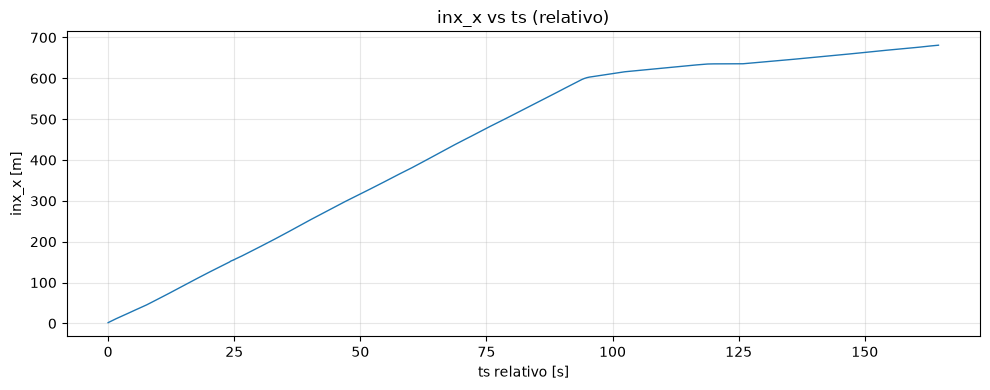

In [5]:
import matplotlib.pyplot as plt

# ts relativo en segundos (1 unidad de ts ~ 1 ms)
t_rel = (df_log["ts"] - df_log["ts"].iloc[0]) / 1000.0

# 1) inx_x vs ts (relativo)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_rel, df_log["inx_x"], lw=1)
ax.set_xlabel("ts relativo [s]")
ax.set_ylabel("inx_x [m]")
ax.set_title("inx_x vs ts (relativo)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

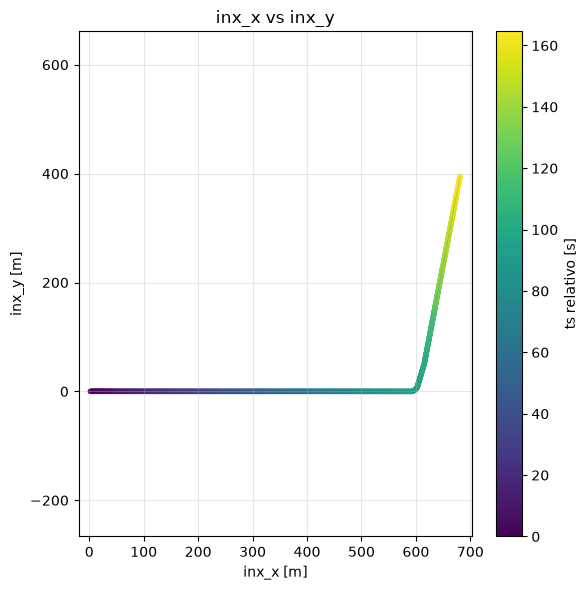

In [6]:
# 2) inx_x vs inx_y (trayectoria en el plano local del INS)
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(df_log["inx_x"], df_log["inx_y"], c=t_rel, cmap="viridis", s=8)
ax.plot(df_log["inx_x"], df_log["inx_y"], lw=0.5, color="gray", alpha=0.5)
ax.set_xlabel("inx_x [m]")
ax.set_ylabel("inx_y [m]")
ax.set_title("inx_x vs inx_y")
ax.set_aspect("equal", adjustable="datalim")
ax.grid(True, alpha=0.3)
fig.colorbar(sc, ax=ax, label="ts relativo [s]")
plt.tight_layout()
plt.show()

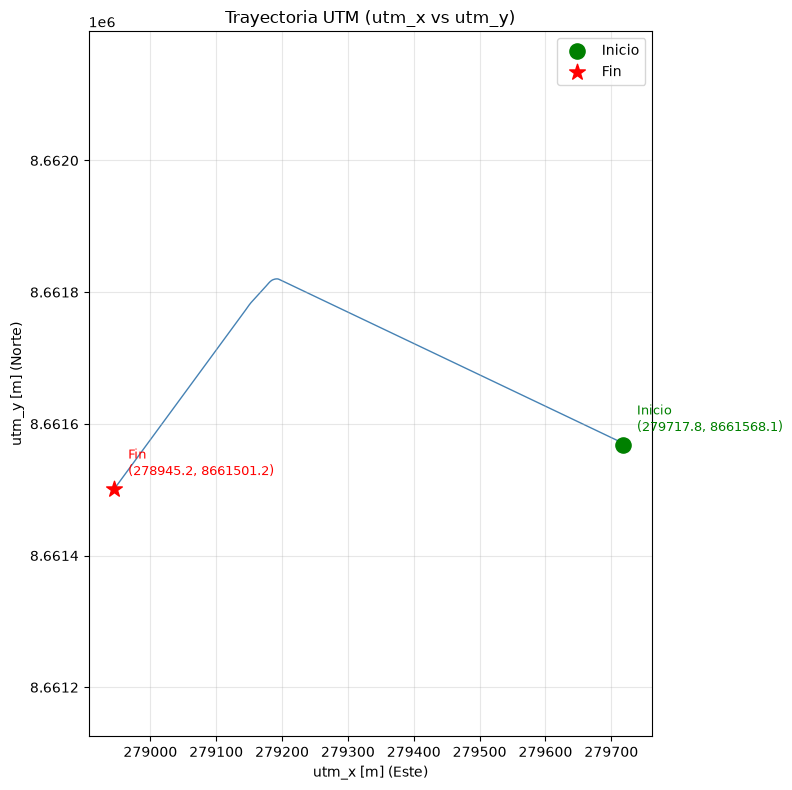

In [7]:
# Trayectoria UTM con identificadores de inicio y fin
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(df_log["utm_x"], df_log["utm_y"], lw=1, color="steelblue", zorder=1)

# Punto inicial y final
x0, y0 = df_log["utm_x"].iloc[0],  df_log["utm_y"].iloc[0]
xf, yf = df_log["utm_x"].iloc[-1], df_log["utm_y"].iloc[-1]

ax.scatter(x0, y0, color="green", s=120, marker="o", zorder=3, label="Inicio")
ax.scatter(xf, yf, color="red",   s=140, marker="*", zorder=3, label="Fin")

ax.annotate(f"Inicio\n({x0:.1f}, {y0:.1f})", (x0, y0),
            textcoords="offset points", xytext=(10, 10), color="green", fontsize=9)
ax.annotate(f"Fin\n({xf:.1f}, {yf:.1f})", (xf, yf),
            textcoords="offset points", xytext=(10, 10), color="red", fontsize=9)

ax.set_xlabel("utm_x [m] (Este)")
ax.set_ylabel("utm_y [m] (Norte)")
ax.set_title("Trayectoria UTM (utm_x vs utm_y)")
ax.set_aspect("equal", adjustable="datalim")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

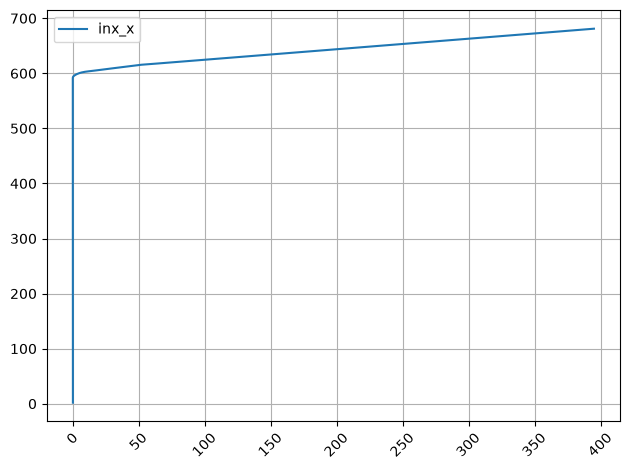

In [8]:
plot_window(df_log, ts_array="inx_y", data_array="inx_x")